In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os

from Geometry_methods import set_geom_fuel_shell, make_settings, set_mat, get_material_by_name
import openmc.deplete as dep
from collections import defaultdict #To use dictionaries to remove dublicates

In [2]:
#Geometry
new_geom = True
inner_fuel_r = 48
outer_fuel_r = 50
outer_moderater_r = 87

with_blanket = True
inner_moderator_height = 84
blanket_or = 100


if new_geom:
    geom, mat= set_geom_fuel_shell(inner_fuel_r,outer_fuel_r,outer_moderater_r,with_blanket=with_blanket,
                               blanket_or=blanket_or, inner_moderator_height=inner_moderator_height, fuel_name="Fuel CA_2")
else:
    openmc.reset_auto_ids()
    geom = openmc.Geometry.from_xml("geometry.xml")
    mat = openmc.Materials.from_xml('materials.xml')

Fuel_CA_1
Fuel_CA_2
Blanket_CA
Fuel_A
Fuel_B
Fuel_C
Air
h2o
d2o
uo2


In [3]:
#Settings
settings = make_settings(geom)

In [4]:
# Depletion chain (e.g., 'chain_endfb71_u235.xml' or your own)
#chain = dep.Chain.from_xml("chain_endfb71_u235.xml")
def openmcRunDepletion(geom, settings, mat):
    chain_file="chain_endfb71_sfr.xml"
    # Depletion operator
    model = openmc.Model(geometry=geom, materials=mat, settings=settings)
    op = dep.CoupledOperator(model,chain_file)
    
    # Take one timestep
    timestep = np.linspace(1,1,3)  # days also only test
    power = 1e6 # watts Needs to be changed
    
    # Deplete using mid-point predictor-corrector
    cecm = openmc.deplete.CECMIntegrator(
        op, timestep, power, timestep_units='d')
    cecm.integrate() 

In [ ]:
openmcRunDepletion(geom, settings, mat)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

          favor of the model.xml file.


 Reading U234 from /root/nndc_hdf5/U234.h5
 Reading U235 from /root/nndc_hdf5/U235.h5
 Reading U238 from /root/nndc_hdf5/U238.h5
 Reading U236 from /root/nndc_hdf5/U236.h5
 Reading Th230 from /root/nndc_hdf5/Th230.h5
 Reading Th232 from /root/nndc_hdf5/Th232.h5
 Reading Be9 from /root/nndc_hdf5/Be9.h5
 Reading Zr90 from /root/nndc_hdf5/Zr90.h5
 Reading Zr91 from /root/nndc_hdf5/Zr91.h5
 Reading Zr92 from /root/nndc_hdf5/Zr92.h5
 Reading Zr94 from /root/nndc_hdf5/Zr94.h5
 Reading Zr96 from /root/nndc_hdf5/Zr96.h5
 Reading N14 from /root/nndc_hdf5/N14.h5
 Reading N15 from /root/nndc_hdf5/N15.h5
 Reading O16 from /root/nndc_hdf5/O16.h5
 Reading O17 from /root/nndc_hdf5/O17.h5
 Reading O18 from /root/nndc_hdf5/O18.h5
 Reading Ar36 from /root/nndc_hdf5/Ar36.h5
 Reading Ar38 from /root/nndc_hdf5/Ar38.h5
 Reading Ar40 from /root/nndc_hdf5/Ar40.h5
 Reading C0 from /root/nndc_hdf5/C0.h5
 Reading H1 from /root/nndc_hdf5/H1.h5
 Reading H2 from /root/nndc_hdf5/H2.h5
 Reading c_H_in_H2O from /root/

 Reading Mo93 from /root/nndc_hdf5/Mo93.h5
 Reading Mo94 from /root/nndc_hdf5/Mo94.h5
 Reading Mo95 from /root/nndc_hdf5/Mo95.h5
 Reading Mo96 from /root/nndc_hdf5/Mo96.h5
 Reading Mo97 from /root/nndc_hdf5/Mo97.h5
 Reading Mo98 from /root/nndc_hdf5/Mo98.h5
 Reading Mo99 from /root/nndc_hdf5/Mo99.h5
 Reading Mo100 from /root/nndc_hdf5/Mo100.h5
 Reading Tc96 from /root/nndc_hdf5/Tc96.h5


          1200K
          2500K


...

 Reading Pm151 from /root/nndc_hdf5/Pm151.h5
 Reading Sm144 from /root/nndc_hdf5/Sm144.h5
 Reading Sm145 from /root/nndc_hdf5/Sm145.h5
 Reading Sm146 from /root/nndc_hdf5/Sm146.h5
 Reading Sm147 from /root/nndc_hdf5/Sm147.h5
 Reading Sm148 from /root/nndc_hdf5/Sm148.h5
 Reading Sm149 from /root/nndc_hdf5/Sm149.h5
 Reading Sm150 from /root/nndc_hdf5/Sm150.h5
 Reading Sm151 from /root/nndc_hdf5/Sm151.h5
 Reading Sm152 from /root/nndc_hdf5/Sm152.h5
 Reading Sm153 from /root/nndc_hdf5/Sm153.h5
 Reading Sm154 from /root/nndc_hdf5/Sm154.h5
 Reading Eu151 from /root/nndc_hdf5/Eu151.h5
 Reading Eu152 from /root/nndc_hdf5/Eu152.h5
 Reading Eu152_m1 from /root/nndc_hdf5/Eu152_m1.h5
 Reading Eu153 from /root/nndc_hdf5/Eu153.h5
 Reading Eu154 from /root/nndc_hdf5/Eu154.h5
 Reading Eu155 from /root/nndc_hdf5/Eu155.h5
 Reading Eu156 from /root/nndc_hdf5/Eu156.h5
 Reading Eu157 from /root/nndc_hdf5/Eu157.h5
 Reading Gd148 from /root/nndc_hdf5/Gd148.h5
 Reading Gd149 from /root/nndc_hdf5/Gd149.h5
 Rea

          1200K


 Reading Pu240 from /root/nndc_hdf5/Pu240.h5
 Reading Pu241 from /root/nndc_hdf5/Pu241.h5
 Reading Pu242 from /root/nndc_hdf5/Pu242.h5
 Reading Pu243 from /root/nndc_hdf5/Pu243.h5
 Reading Pu244 from /root/nndc_hdf5/Pu244.h5
 Reading Pu246 from /root/nndc_hdf5/Pu246.h5
 Reading Am241 from /root/nndc_hdf5/Am241.h5
 Reading Am242 from /root/nndc_hdf5/Am242.h5
 Reading Am242_m1 from /root/nndc_hdf5/Am242_m1.h5
 Reading Am243 from /root/nndc_hdf5/Am243.h5
 Reading Am244 from /root/nndc_hdf5/Am244.h5
 Reading Am244_m1 from /root/nndc_hdf5/Am244_m1.h5
 Reading Cm240 from /root/nndc_hdf5/Cm240.h5
 Reading Cm241 from /root/nndc_hdf5/Cm241.h5
 Reading Cm242 from /root/nndc_hdf5/Cm242.h5
 Reading Cm243 from /root/nndc_hdf5/Cm243.h5
 Reading Cm244 from /root/nndc_hdf5/Cm244.h5
 Reading Cm245 from /root/nndc_hdf5/Cm245.h5
 Reading Cm246 from /root/nndc_hdf5/Cm246.h5
 Reading Cm247 from /root/nndc_hdf5/Cm247.h5
 Reading Cm248 from /root/nndc_hdf5/Cm248.h5
 Reading Cm249 from /root/nndc_hdf5/Cm249.h

          1200K


 Reading Cf251 from /root/nndc_hdf5/Cf251.h5
 Reading Cf252 from /root/nndc_hdf5/Cf252.h5
 Reading Cf253 from /root/nndc_hdf5/Cf253.h5
 Reading Cf254 from /root/nndc_hdf5/Cf254.h5
 Reading Es253 from /root/nndc_hdf5/Es253.h5
 Reading Es254 from /root/nndc_hdf5/Es254.h5
 Reading Es255 from /root/nndc_hdf5/Es255.h5
 Reading Fm255 from /root/nndc_hdf5/Fm255.h5
 Maximum neutron transport energy: 20000000 eV for Li6
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.27929
        2/1    0.96205
        3/1    1.00175
        4/1    0.97192
        5/1    1.01163
        6/1    1.01366
        7/1    0.99882
        8/1    0.98220
        9/1    1.01412
       10/1    1.02890
       11/1    0.99350
       12/1    1.01292    1.00321 +/- 0.00971
       13/1    1.00823    1.00488 +/- 0.00585
       14/1    1.00929    1.00598 +/- 0.0

#Fra chatgpt
# Load depletion results
results = openmc.deplete.Results(filename="depletion_results.h5")
time, keff = results.get_keff()

print(time)

print(results.get_step_where(1e-6)) #units days
materials = results.export_to_materials(1)
materials.export_to_xml("dep_materials_210126.xml")
#print(materials)

In [7]:
# Load materials from XML
materials = openmc.Materials.from_xml("materials-finish.xml")

#Using fond materials 
materials = results.export_to_materials(1)
# Collect all nuclides present
nuclides = []

mat = get_material_by_name("Fuel_CA_2",materials)
for nuclide, amount,_ in mat.nuclides:
    nuclides.append([nuclide,amount])

print(nuclides)

[['Ac225', np.float64(1.0545805399341408e-53)], ['Ac227', np.float64(4.390486726079483e-24)], ['Am241', np.float64(1.4018804498550958e-33)], ['Bi208', np.float64(3.4687743249709116e-30)], ['Bi209', np.float64(3.455401714876526e-38)], ['Bi210', np.float64(5.997172935070582e-35)], ['Ce140', np.float64(5.559042269845877e-88)], ['Cf249', np.float64(1.8734938608824788e-31)], ['Cm241', np.float64(2.181437826848029e-31)], ['Cm245', np.float64(9.200091913982556e-33)], ['Dy156', np.float64(1.5899482892053497e-34)], ['Dy158', np.float64(3.141645795087513e-32)], ['Dy160', np.float64(7.122565403719861e-33)], ['Er162', np.float64(2.1789299416130828e-32)], ['Er164', np.float64(1.0757418088547616e-33)], ['F19', np.float64(0.06489570854826661)], ['Gd148', np.float64(1.9523167438671558e-30)], ['Gd150', np.float64(5.944979711875302e-31)], ['Gd152', np.float64(8.573637015738017e-33)], ['H1', np.float64(4.3900334372548136e-30)], ['He4', np.float64(2.42378485147424e-14)], ['Li6', np.float64(4.0769248916131

In [8]:
import openmc.data
import re
decay = openmc.data.Decay.from_endf("../endf-b-vii.1/decay/dec-094_Pu_239.endf")

def make_AZ_Str(AZ):
    #Makes sure that number has 3 digits as in endf files and turns the numbers into strings
    if AZ < 10:
        AZstr = f"00{AZ}"
    elif AZ < 100:
        AZstr = f"0{AZ}"
    else:
        AZstr = f"{AZ}"
    return AZstr

def has_alpha_decay(nuclide):
    #Checking if atoms have alpha decay
    nuclide_name=nuclide[0]
    Z, A, m =openmc.data.zam(nuclide_name)

    #Isolating the atomic symbol
    #print(nuclide_name)
    match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
    #print(match)
    m1=0
    if match == None:
        match = re.match(r"([A-Za-z]+)",nuclide_name)
        symbol =match.groups()[0]
    else:
        symbol, _,_ ,m1 =match.groups()

    #print(symbol,m1)
    Z = make_AZ_Str(Z)
    A = make_AZ_Str(A)
    #print(Z,symbol,A)
    try:
        if m1 != 0:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
        else:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")
        for mode in dec.modes:
            if mode.modes[0] == "alpha":
                return True
        return False   
    except KeyError:
        print("Error")
        return False

#print(has_alpha_decay(nuclides[3]))        
alpha_nuclides = [nuc for nuc in nuclides if has_alpha_decay(nuc)]

print(alpha_nuclides)

[['Ac225', np.float64(1.0545805399341408e-53)], ['Ac227', np.float64(4.390486726079483e-24)], ['Am241', np.float64(1.4018804498550958e-33)], ['Bi209', np.float64(3.455401714876526e-38)], ['Bi210', np.float64(5.997172935070582e-35)], ['Cf249', np.float64(1.8734938608824788e-31)], ['Cm241', np.float64(2.181437826848029e-31)], ['Cm245', np.float64(9.200091913982556e-33)], ['Gd148', np.float64(1.9523167438671558e-30)], ['Gd150', np.float64(5.944979711875302e-31)], ['Gd152', np.float64(8.573637015738017e-33)], ['Nd144', np.float64(4.003951644788272e-69)], ['Np237', np.float64(3.4345044005807077e-34)], ['Pa231', np.float64(2.1617163213962716e-16)], ['Pu237', np.float64(8.689227786521875e-32)], ['Pu241', np.float64(3.301989179907167e-40)], ['Ra223', np.float64(1.961138502420505e-30)], ['Ra226', np.float64(2.6282132428580635e-22)], ['Sm146', np.float64(6.072845758444822e-35)], ['Sm148', np.float64(6.209905828251156e-50)], ['Th227', np.float64(9.653072502323215e-29)], ['Th229', np.float64(5.833

In [9]:
#Is not neasecary when only looking at one material
merged = defaultdict(float)

for name, value in alpha_nuclides:
    merged[name] += value

alpha_nuclides = [[name, val] for name, val in merged.items()]
print(alpha_nuclides)

[['Ac225', np.float64(1.0545805399341408e-53)], ['Ac227', np.float64(4.390486726079483e-24)], ['Am241', np.float64(1.4018804498550958e-33)], ['Bi209', np.float64(3.455401714876526e-38)], ['Bi210', np.float64(5.997172935070582e-35)], ['Cf249', np.float64(1.8734938608824788e-31)], ['Cm241', np.float64(2.181437826848029e-31)], ['Cm245', np.float64(9.200091913982556e-33)], ['Gd148', np.float64(1.9523167438671558e-30)], ['Gd150', np.float64(5.944979711875302e-31)], ['Gd152', np.float64(8.573637015738017e-33)], ['Nd144', np.float64(4.003951644788272e-69)], ['Np237', np.float64(3.4345044005807077e-34)], ['Pa231', np.float64(2.1617163213962716e-16)], ['Pu237', np.float64(8.689227786521875e-32)], ['Pu241', np.float64(3.301989179907167e-40)], ['Ra223', np.float64(1.961138502420505e-30)], ['Ra226', np.float64(2.6282132428580635e-22)], ['Sm146', np.float64(6.072845758444822e-35)], ['Sm148', np.float64(6.209905828251156e-50)], ['Th227', np.float64(9.653072502323215e-29)], ['Th229', np.float64(5.833

Ac227 amount:	 4.39e-24, 	activity of most intens line:	 2.92e-35
Pa231 amount:	 2.16e-16, 	activity of most intens line:	 3.68e-29
Ra226 amount:	 2.63e-22, 	activity of most intens line:	 3.41e-33
Th227 amount:	 9.65e-29, 	activity of most intens line:	 1e-35
Th230 amount:	 2.09e-14, 	activity of most intens line:	 4.64e-27
Th232 amount:	 1.12e-16, 	activity of most intens line:	 1.37e-34
U234 amount:	 2.7e-06, 	activity of most intens line:	 1.72e-19
U235 amount:	 0.000302, 	activity of most intens line:	 5.19e-21
U236 amount:	 1.38e-06, 	activity of most intens line:	 9.58e-22
U238 amount:	 0.00573, 	activity of most intens line:	 2.22e-20

Array of nuclide and the max activity
Ac225 4.2894284798595883e-60
Ac227 2.9156358494642304e-35
Am241 6.035904716899558e-44
Bi209 3.991343934068001e-65
Bi210 7.602779765898584e-47
Cf249 9.636940096760952e-42
Cm241 3.676206820237889e-40
Cm245 2.2156951098406811e-44
Gd148 5.748214132341057e-40
Gd150 7.294892067129965e-45
Gd152 1.7436645300488787e-5

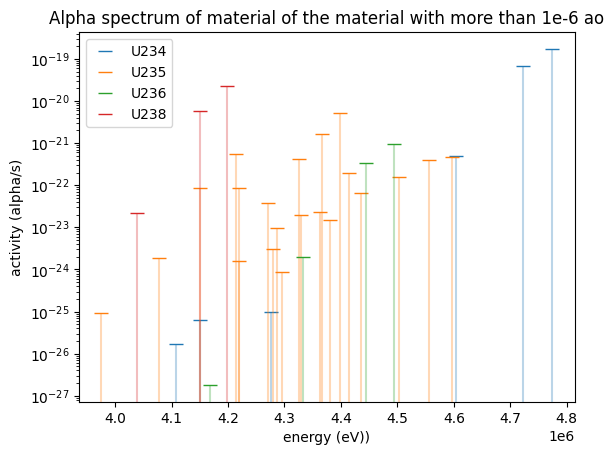

In [10]:
def alpha_decay_values(nuclide):
    #Returning possible alpha decay and branching ratios
    nuclide_name=nuclide[0]
    nuclide_amount=nuclide[1]
    Z, A, m =openmc.data.zam(nuclide_name)

    #Isolating the atomic symbol
    #print(nuclide_name)
    match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
    #print(match)
    m1=0
    if match == None:
        match = re.match(r"([A-Za-z]+)",nuclide_name)
        symbol =match.groups()[0]
    else:
        symbol, _,_ ,m1 =match.groups()

    #print(symbol,m1)
    Z = make_AZ_Str(Z)
    A = make_AZ_Str(A)
    #print(Z,symbol,A)
    if m1 != 0:
        dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
    else:
        dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")
    try:
        decay_constant = dec.decay_constant.nominal_value #log(2)/half_life
    except ValueError as e:
        print(f"Skipping {dec.nuclide['name']} amount: {nuclide_amount:.3g}: {e}")
        decay_constant = 0
    if len(dec.spectra)!=0:
        alpha_data=dec.spectra['alpha']
        energies = [float(item['energy'].nominal_value) for item in alpha_data['discrete']] #can be continuous or discrete
        intensities  = [float(item['intensity'].nominal_value) for item in alpha_data['discrete']]
        

        activities = [decay_constant*nuclide_amount*intensity for intensity in intensities] #Calculation of activities
        if sum(activities)>1e-25:
            print(dec.nuclide['name'], f"amount:\t {nuclide_amount:.3g}, \tactivity of most intens line:\t {max(activities):.3g}")
            line, =plt.plot(energies, activities, "_", label=dec.nuclide['name'],ms=10)
            plt.vlines(energies,[0]*len(energies),activities,line.get_color(),alpha=0.3)
        elif sum(activities)>1e-35:
            print(dec.nuclide['name'], f"amount:\t {nuclide_amount:.3g}, \tactivity of most intens line:\t {max(activities):.3g}")
        return [nuclide_name,activities,energies]
    else:
        activity=decay_constant*nuclide_amount
        print(dec.nuclide['name'],"activity: ",f"{activity:.3g}"," has no spectra")
    return None


alpha_nucs_activity=[alpha_decay_values(nuc) for nuc in alpha_nuclides]

alpha_nucs_activity=[nuc for nuc in alpha_nucs_activity if nuc is not None]

plt.title("Alpha spectrum of material of the material with more than 1e-6 ao")
plt.semilogy()
plt.xlabel("energy (eV))")
plt.ylabel("activity (alpha/s)")

plt.legend()
print('\nArray of nuclide and the max activity')
for nuc in alpha_nucs_activity:
    print(nuc[0],max(nuc[1]))

In [11]:
def alpha_decay_values_from_material(material,geom,cell_name,show_discarded=False):
    #Takes a material and returns the amount of alpha decay pr L
    result = []
    material_mass = 0
    material_cell = geom.get_cells_by_name(cell_name)[0]
    material_cell.fill = material
    try:
        material_cell.volume = material.volume
        print('material.volume: ',material.volume)
    except Exception as e:
        print(f'Error no material volume defined {e}')
    for nuclide_name, nuclide_amount_percent,_ in material.nuclides:
        print(nuclide_name, nuclide_amount_percent)
        Z, A, m =openmc.data.zam(nuclide_name)
        print(f'number of {nuclide_name} atoms {material_cell.atoms[nuclide_name]}')
        nuclide_amount = material_cell.atoms[nuclide_name]
        nuclide_mass = openmc.data.atomic_mass(nuclide_name)
        total_mass = nuclide_mass*nuclide_amount
        print('nuclide mass', nuclide_mass, 'total mass ',total_mass*1.6605402e-27)
        material_mass += total_mass
        
        #Isolating the atomic symbol
        match = re.match(r"([A-Za-z]+)(\d+)(_)(m\d+)",nuclide_name)
        #print(match)
        m1=0
        if match == None:
            match = re.match(r"([A-Za-z]+)",nuclide_name)
            symbol =match.groups()[0]
        else:
            symbol, _,_ ,m1 =match.groups()
    
        Z = make_AZ_Str(Z)
        A = make_AZ_Str(A)

        #Getting decay data from ground state or excited (m1)
        if m1 != 0:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}{m1}.endf")
        else:
            dec = openmc.data.Decay.from_endf(f"../endf-b-vii.1/decay/dec-{Z}_{symbol}_{A}.endf")

        #Seeing if decay constant is possible to return
        try:
            decay_constant = dec.decay_constant.nominal_value #log(2)/half_life
        except ValueError as e:
            if show_discarded:
                print(f"Skipping {dec.nuclide['name']} amount: {nuclide_amount:.3g}: {e}")
                decay_constant = 0
        
        #Finding the spectra and calculating the activity
        if len(dec.spectra)!=0 and has_alpha_decay([nuclide_name]):
            alpha_data=dec.spectra['alpha']
            energies = [float(item['energy'].nominal_value) for item in alpha_data['discrete']] #can be continuous or discrete
            intensities  = [float(item['intensity'].nominal_value) for item in alpha_data['discrete']]

            activities = [decay_constant*nuclide_amount*intensity for intensity in intensities] #Calculation of activities
            result.append([nuclide_name,activities,energies])
        else:
            if show_discarded:
                activity=decay_constant*nuclide_amount
                print(dec.nuclide['name'],f"activity: {activity:.3g} has no alpha spectra")

    material_mass = material_mass*1.6605402e-27
    print(f'total mass of {cell_name} filled with {material.name} is {material_mass:.3g} kg which gives a density of {material_mass*1000/material_cell.volume:.3g} g/cm^3')
    return result, material_mass
fuel = get_material_by_name("Fuel_CA_2",materials)
#print(fuel)
#alpha_spectra_data1,total_mass = alpha_decay_values_from_material(fuel,geom,'fuel')


#print([d[0] for d in alpha_spectra_data1])


In [12]:
def plot_material_energy_spectra(alpha_spectra_data,total_mass,plot_threshold=1e-5,show_discarded=False):
    fig,ax = plt.subplots()
    
    ax.set_title(f"Alpha spectrum of material of the material with more than {plot_threshold} alpha/(kg*s)")
    ax.semilogy()
    ax.set_xlabel("energy (eV)")
    ax.set_ylabel("activity (alpha/s*kg)")
    for name, activities, energies  in alpha_spectra_data:
        activities_pr_kg = activities/total_mass
        if sum(activities_pr_kg) > plot_threshold:
            line, =ax.plot(energies, activities_pr_kg, "_", label=name,ms=10)
            ax.vlines(energies,[0]*len(energies),activities_pr_kg,line.get_color(),alpha=0.3)
        elif show_discarded:
            print(f'{name} with a total activity of {sum(activities_pr_kg):.2g} alpha/(kg*s) is not plotted')
    ax.legend()
    
#plot_material_energy_spectra(alpha_spectra_data1,total_mass,plot_threshold=1e-6)

material.volume:  1430459.288563938
Li6 0.026561499999999995
number of Li6 atoms 3.840609608943579e+27
nuclide mass 6.01512288742 total mass  38.36136590154519
Li7 0.3234384999999999
number of Li7 atoms 4.676697517091646e+28
nuclide mass 7.01600343426 total mass  544.851897902102
F19 0.59
number of F19 atoms 8.530992862890695e+28
nuclide mass 18.99840316207 total mass  2691.3245440362966
Th230 1.2000000000000002e-05
number of Th230 atoms 1.735117192452345e+24
nuclide mass 230.033132267 total mass  0.6627787871919346
Th232 0.05998800000000002
number of Th232 atoms 8.673850845069275e+27
nuclide mass 232.038053606 total mass  3342.1085966203977
total mass of blanket filled with Blanket_CA is 6.62e+03 kg which gives a density of 4.63 g/cm^3


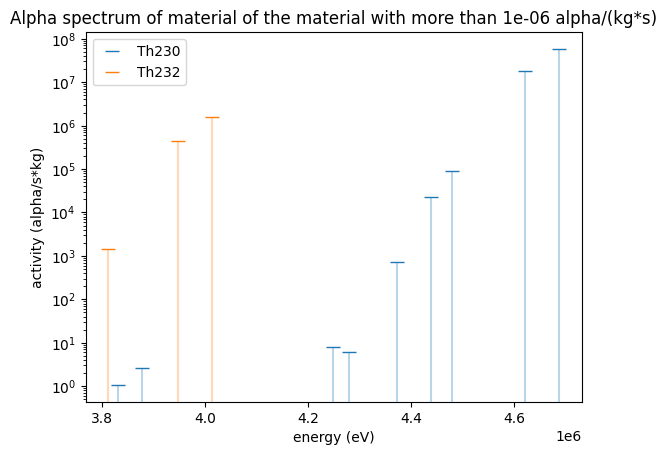

In [13]:
openmc.reset_auto_ids()
chosen_material = get_material_by_name("Blanket_CA",materials = openmc.Materials.from_xml('materials.xml'))
alpha_spectra_data,total_mass = alpha_decay_values_from_material(chosen_material,geom,'blanket')
plot_material_energy_spectra(alpha_spectra_data,total_mass,plot_threshold=1e-6)

In [14]:
from pathlib import Path
path = Path("../endf-b-vii.1/decay/dec-000_Nn_001.endf")

print("Exists:", path.exists())
print("Absolute path:", path.resolve())

Exists: True
Absolute path: /root/endf-b-vii.1/decay/dec-000_Nn_001.endf
